### **Покажем некоторые методы EDA.**

_Установим настройки для графиков._

In [1]:
from locale import currency

import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=0.8,
    rc={
        "axes.facecolor": "#FAF7F8",
        "figure.facecolor": "#FAF7F8",
        "grid.color": "#E5E0E2",
        "grid.linewidth": 0.8,
    }
)


sns.set_palette([
    "#E8A2B8",  # розовый
    "#9BC5A3",  # зелёный
    "#9B4F64",  # бордовый
    "#8FBBD9",  # голубой
    "#B39BC8",  # фиолетовый
])

_Возьмем данные с кик-старта до обработки признаков._

In [2]:
import pandas as pd
data = pd.read_csv('../Практика 1-2/ks.csv')
data.head()

,Название,Категория,Главная категория,Валюта,Дедлайн,Дата публикации,Состояние,Инвесторов,Страна,Собрано в долларах,Цель в долларах
0,"Don't Call it a Comeback ""Telescopes""",Music,Music,USD,2013-01-10,2012-12-09 06:03:52,successful,23,US,600.00,600.00
1,Arcade County (Canceled),Games,Games,USD,2012-04-29,2012-03-30 23:40:45,canceled,5,US,71.00,9000.00
2,Hayashi Skate Co. Solar Skateboard backpack,Accessories,Fashion,CAD,2017-07-22,2017-05-23 23:00:13,canceled,8,CA,360.36,2391.77
3,Me & You Coordinating Sunglasses- Optical Qual...,Accessories,Fashion,USD,2016-11-18,2016-10-19 22:06:41,failed,20,US,502.00,10000.00
4,New Carts for Istanbul Street Food Vendors,Food,Food,USD,2015-05-17,2015-04-17 18:10:47,successful,62,US,2414.00,1400.00


_Рассмотрим признак главная категория. Узнаем среднее значение по каждой категории._

In [3]:
#сгруппируем по главной категории
main_category = data.groupby('Главная категория')

#узнаем среднее значение таргета для каждой категории
mean_target = main_category['Собрано в долларах'].mean()
#получим Series объект, название категорий - индексы,
#средние таргеты - значения

_Теперь изобразим график, отражающий какие в среднем значения таргета принимают объекты, принадлежащие определенной категории._

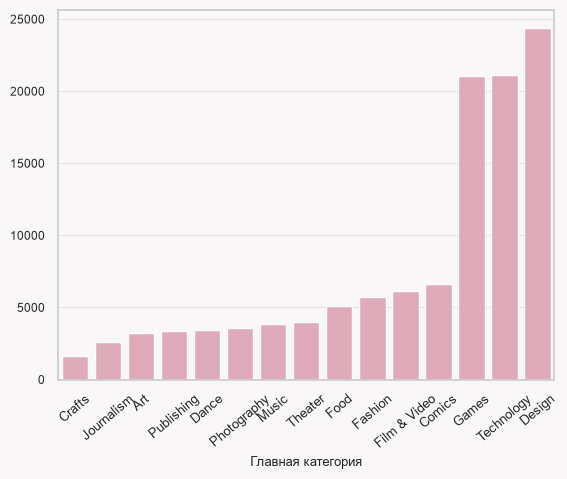

In [4]:
#для начала отсортируем, чтобы столбики шли от меньшего к большему
mean_target = mean_target.sort_values()

sns.barplot(
    x=mean_target.index,
    y=mean_target.values
)

plt.xticks(rotation=40, fontsize=9)
plt.show()

_Мы видим, что изменения признака главная категория влияет на таргет._

_Но стоит проверить, какое количество объектов относится к каждой из категорий. Ведь Games, Technology и Design могут оказаться выбросами._

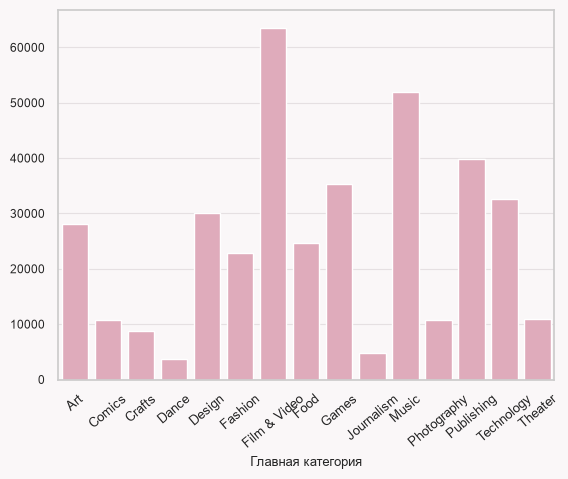

In [5]:
#посчитаем кол-во не пропущенных значений в каждой категории
count_category = main_category['Собрано в долларах'].count()

#изобразим
sns.barplot(
    x=count_category.index,
    y=count_category.values
)

plt.xticks(rotation=40, fontsize=9)
plt.show()


_Видим, что в каждой категории участвует достаточное количество объектов._

### **Теперь нарисуем ящики с усами для признака валют.**
_То есть узнаем, посмотрим на распределение значений таргета по каждой валюте._

In [6]:
#для этого нам нужно создать словарь
#валюта: [все значения таргета]
currency_dict = {}

#сначала узнаем все уникальные значения валют
uniq_vals = data['Валюта'].unique()
uniq_vals

<StringArray>
['USD', 'CAD', 'EUR', 'CHF', 'GBP', 'AUD', 'DKK', 'SEK', 'NZD', 'HKD', 'MXN',
 'NOK', 'JPY', 'SGD']
Length: 14, dtype: str

_Теперь соберем значения, таргетов, которые принимает объект с признаком определенной валюты._

In [7]:
for currency in uniq_vals:
    #создадим булевую маску для отбора таргетов
    #по заданной валюте
    mask = data['Валюта'] == currency

    #теперь отберем только нужные значения столбцов
    currency_dict[currency] = data[mask]['Собрано в долларах']

currency_dict

{'USD': 0           600.00
 1            71.00
 3           502.00
 4          2414.00
 5         10030.88
             ...   
 378654      505.00
 378655    18808.00
 378658        0.00
 378659      200.00
 378660     4847.00
 Name: Собрано в долларах, Length: 295365, dtype: float64,
 'CAD': 2          360.36
 34           0.00
 38         226.82
 42          13.56
 58        2437.17
            ...   
 378471     115.39
 378504    1426.42
 378525    2690.16
 378601    1321.19
 378640       0.00
 Name: Собрано в долларах, Length: 14962, dtype: float64,
 'EUR': 8          4395.53
 54            0.00
 69          485.48
 74         2876.09
 84        50392.41
             ...   
 378609        0.00
 378616    18151.69
 378623      911.53
 378649        0.00
 378652        0.00
 Name: Собрано в долларах, Length: 17405, dtype: float64,
 'CHF': 16         3133.37
 241         100.72
 541        1987.16
 687           0.00
 1158        201.43
             ...   
 377139     4920.65
 377712 

_Нарисуем ящики с усами._

(0.0, 5000.0)

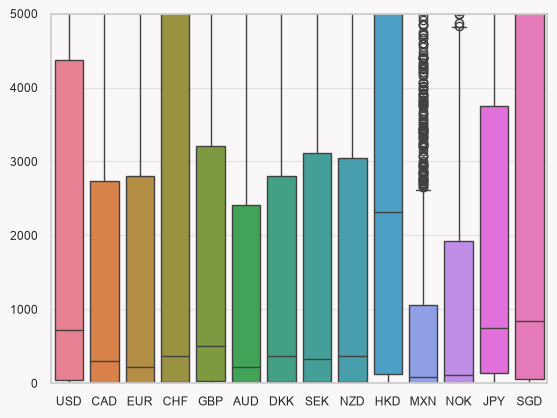

In [10]:
sns.boxplot(currency_dict)
#изменим размерность вертикальной оси
plt.ylim(0, 5000)

_Экстремальных значений достаточно много. Но так как сами ящики отличаются между собой, мы оставим этот признак._